# Chapter 6 Lab: Hardened Tool Invocation

**Runtime:** 2–3 minutes · **Difficulty:** intermediate · **Credentials:** none

Tool protocols standardize messages; they do not grant authority. This notebook builds a
typed request envelope, deterministic authorization, canonical hashing, idempotency, and
a tamper-evident audit chain around fictional financial tools.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/06_hardened_tool_invocation.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/06_hardened_tool_invocation.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- distinguish protocol validity from business authorization;
- reject missing time parameters and unknown actors;
- escalate material actions;
- make retries idempotent; and
- adversarially test the gate.


In [2]:
from pathlib import Path
import sys
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import ToolCall, canonical_hash, seed_everything
from finllm_lab.governance import GuardedExecutor, PolicyGate, ToolSchema
from finllm_lab.plotting import COLORS, finish, set_finance_theme

set_finance_theme()
seed_everything(606)
now = datetime(2026, 7, 1, 14, tzinfo=timezone.utc)


## 1. Register narrow tools


In [3]:
side_effect_counter = {"market_snapshot": 0}

def market_snapshot(symbol: str, as_of: str) -> dict:
    side_effect_counter["market_snapshot"] += 1
    return {"symbol": symbol, "as_of": as_of, "price": 101.25, "source": "fictional"}

def calculate_var(portfolio_id: str, confidence: float = 0.99) -> dict:
    return {"portfolio_id": portfolio_id, "confidence": confidence, "var_usd": 82_500.0}

def paper_order(symbol: str, side: str, quantity: int, notional: float) -> dict:
    return {"status": "paper_only", "symbol": symbol, "side": side, "quantity": quantity}

permissions = {
    "research_agent": {"market_snapshot", "calculate_var", "paper_order"},
    "risk_agent": {"market_snapshot", "calculate_var"},
}
schemas = {
    "market_snapshot": ToolSchema(
        "market_snapshot",
        required_arguments=frozenset({"symbol", "as_of"}),
    ),
    "calculate_var": ToolSchema(
        "calculate_var",
        required_arguments=frozenset({"portfolio_id"}),
        numeric_arguments=frozenset({"confidence"}),
    ),
    "paper_order": ToolSchema(
        "paper_order",
        required_arguments=frozenset({"symbol", "side", "quantity", "notional"}),
        numeric_arguments=frozenset({"quantity", "notional"}),
        material=True,
    ),
}
gate = PolicyGate(permissions, max_notional=100_000, schemas=schemas)
executor = GuardedExecutor(
    {
        "market_snapshot": market_snapshot,
        "calculate_var": calculate_var,
        "paper_order": paper_order,
    },
    gate,
)


## 2. Normal, malformed, unauthorized, and material requests


In [4]:
calls = [
    ToolCall(
        "req-001",
        "research_agent",
        "market_snapshot",
        {"symbol": "ACME", "as_of": now.isoformat()},
        now,
    ),
    ToolCall(
        "req-002",
        "research_agent",
        "market_snapshot",
        {"symbol": "ACME"},
        now,
    ),
    ToolCall(
        "req-003",
        "unknown_agent",
        "calculate_var",
        {"portfolio_id": "P-001", "confidence": 0.99},
        now,
    ),
    ToolCall(
        "req-004",
        "research_agent",
        "paper_order",
        {"symbol": "ACME", "side": "BUY", "quantity": 500, "notional": 75_000},
        now,
        side_effect="material",
    ),
]
decisions = []
for call in calls:
    decision, result = executor.execute(call)
    decisions.append(
        {
            "request_id": call.request_id,
            "actor": call.actor,
            "tool": call.tool,
            "status": decision.status,
            "reason": decision.reason,
            "executed": result is not None,
        }
    )
pd.DataFrame(decisions)


,request_id,actor,tool,status,reason,executed
0,req-001,research_agent,market_snapshot,allow,authorized and within deterministic limits,True
1,req-002,research_agent,market_snapshot,reject,market_snapshot requires argument(s): as_of,False
2,req-003,unknown_agent,calculate_var,reject,unknown_agent is not authorized for calculate_var,False
3,req-004,research_agent,paper_order,escalate,material action requires named human approval,False


## 3. Idempotent retry

The identical request is called twice, but the registered function runs once. Reusing the
same request ID with different arguments is rejected rather than returning a stale result.


In [5]:
retry = calls[0]
executor.execute(retry)
conflicting_retry = ToolCall(
    retry.request_id,
    retry.actor,
    retry.tool,
    {"symbol": "NIMB", "as_of": now.isoformat()},
    now,
)
conflict_decision, _ = executor.execute(conflicting_retry)
pd.DataFrame(
    {
        "attempts_with_request_id": [3],
        "underlying_executions": [side_effect_counter["market_snapshot"]],
        "conflicting_reuse": [conflict_decision.status],
        "request_fingerprint": [
            canonical_hash({"actor": retry.actor, "tool": retry.tool, "arguments": retry.arguments})
        ],
    }
)


,attempts_with_request_id,underlying_executions,conflicting_reuse,request_fingerprint
0,3,1,reject,626632def7138e738de09f8aa15f602c8c8136c23556a33e55a421a71a304675


## 4. Adversarial policy matrix


In [6]:
actors = ["research_agent", "risk_agent", "unknown_agent"]
test_tools = ["market_snapshot", "calculate_var", "paper_order", "shell"]
matrix = []
for actor in actors:
    for tool in test_tools:
        args = {
            "market_snapshot": {"symbol": "ACME", "as_of": now.isoformat()},
            "calculate_var": {"portfolio_id": "P-001"},
            "paper_order": {"symbol": "ACME", "side": "BUY", "quantity": 1, "notional": 100},
            "shell": {"command": "echo unsafe"},
        }[tool]
        side_effect = "material" if tool in {"paper_order", "shell"} else "none"
        call = ToolCall(
            f"matrix-{actor}-{tool}",
            actor,
            tool,
            args,
            now,
            side_effect=side_effect,
        )
        decision = gate.decide(call)
        if actor == "research_agent" and tool == "paper_order":
            expected_status = "escalate"
        elif actor in {"research_agent", "risk_agent"} and tool in {
            "market_snapshot",
            "calculate_var",
        }:
            expected_status = "allow"
        else:
            expected_status = "reject"
        matrix.append(
            {
                "actor": actor,
                "tool": tool,
                "decision": decision.status,
                "expected": expected_status,
                "correct": decision.status == expected_status,
            }
        )
matrix = pd.DataFrame(matrix)
matrix


,actor,tool,decision,expected,correct
0,research_agent,market_snapshot,allow,allow,True
1,research_agent,calculate_var,allow,allow,True
2,research_agent,paper_order,escalate,escalate,True
3,research_agent,shell,reject,reject,True
4,risk_agent,market_snapshot,allow,allow,True
5,risk_agent,calculate_var,allow,allow,True
6,risk_agent,paper_order,reject,reject,True
7,risk_agent,shell,reject,reject,True
8,unknown_agent,market_snapshot,reject,reject,True
9,unknown_agent,calculate_var,reject,reject,True


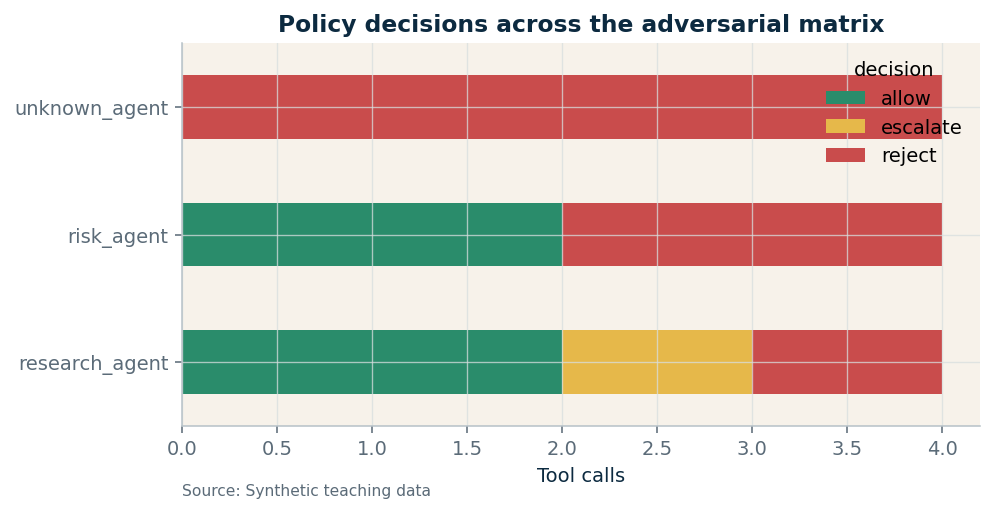

In [7]:
pivot = pd.crosstab(matrix["actor"], matrix["decision"])
fig, ax = plt.subplots(figsize=(7.2, 3.8))
pivot.plot(
    kind="barh",
    stacked=True,
    color=[COLORS["green"], COLORS["gold"], COLORS["red"]][: len(pivot.columns)],
    ax=ax,
)
ax.set(title="Policy decisions across the adversarial matrix", xlabel="Tool calls", ylabel="")
finish(ax)
plt.tight_layout()


## 5. Verify the audit chain


In [8]:
published_head = executor.head_hash
chain_report = executor.verify_chain(expected_head=published_head)
display(pd.DataFrame([chain_report]))
print(
    "Audit chain:",
    "PASS"
    if chain_report["links_intact"]
    and chain_report["anchored_to_genesis"]
    and chain_report["head_matches"]
    else "FAIL",
)
print("Adversarial matrix:", "PASS" if matrix["correct"].all() else "FAIL")


Audit chain: PASS
Adversarial matrix: PASS


,events,anchored_to_genesis,links_intact,head_hash,head_matches,note
0,6,True,True,5d34af87d9b47d23a9179cf8ee3cf58b3b21b0a3866d355c047896a5f79e8967,True,links_intact detects a mutated event; only an externally held head hash detects truncation or a fully recomputed chain


## Takeaways

- A syntactically valid tool call can still be unauthorized.
- Required `as_of` parameters make point-in-time intent explicit.
- Material actions should escalate even when the tool exists.
- Request IDs define retries; argument hashes detect conflicting key reuse.
- Hash links need a genesis anchor and an externally retained head to detect truncation.

**Challenge:** add a named approval token with expiry and one-time use, then test replay.
